In [1]:
# Libraries
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.io import mmread
import networkx as nx
from scipy.optimize import minimize_scalar
from time import sleep

In [2]:
# Weights: must X_i >= 0 and sum(X) = 1 (X_i in [0,1])
# They are not probabilities in a statistical sense. They measure how much the optimizer believes each vertex belongs to the clique.
# Larger weight: node i is very important
# Smaller weight: node i is probably outside the clique
#X = np.random.random(((A2.shape[1], 1)))
#X = X/sum(X)
#X

In [3]:
# We must maximize the function: f(X) = X.T @ A2 @ X
# From theory: if the maximum clique C has size s, the maximum f(X) = 1 - 1/s
# Also: X_i in C = 1/s, 0 otherwise (wiegths corresponding to nodes in the maximum clique will have value 1/s)
#f_x = X.T @ A2 @ X # Since A_ij = 1 only if an edge exists, the objective is the weighted sum of all edges.
#print('f(x) =', round(float(f_x), 5))
#max_f_x = 1 - (1/4)
#print('max_f(x) =', max_f_x)

Gradient: since differentiating with respect to one coordinate $x_k$ results in $2$ identical sums $\sum_{j}{A_{kj}x_j} + \sum_{i}{A_{ik}x_i}$ and since the graph is undirected ($A=A^T$), the two sums are identical. Therefore, $\frac{\partial f}{\partial x_k}=2\sum_{j}{A_{kj} x_j}$ or, in vector notation, $\nabla f(x)=2Ax$.

In [4]:
#grad = 2 * A2 @ X
#print(grad)
#i = np.argmax(grad)
#s = np.zeros_like(X)
#s[i] = 1.0
#print(s)

In [5]:
def plots(experiments, max_clique, highlight_best=True, highlight_avg=True):

    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(20, 10))

    ax1, ax2, ax3, ax4 = axes.flatten()

    # Find the best experiment
    clique_sizes = [
        exp["Clique"][-1] # List of last clique lengths (at convergence of each experiment)
        for exp in experiments]
    
    best_clique = np.max(clique_sizes) # Maximum clique size found

    max_clique_idx = [
        i for i, clique in enumerate(clique_sizes) # Indices of experiments that found the maximum clique
        if clique == best_clique]

    best_idx = min(
        max_clique_idx,
        key=lambda i: experiments[i]["Time"][-1]) # Among those, select the one with minimum time
    
    # General grid
    for ax in axes.flatten():
        ax.grid(
            True,
            linestyle="--",
            linewidth=0.5,
            alpha=0.7)

    # Plot all experiments
    for i, exp in enumerate(experiments):

        # Objective vs Iterations
        ax1.plot(
            exp["Objective function"],
            color = 'blue',
            alpha=0.1)
        
        # Objective vs Time
        ax2.plot(
            exp["Time"],
            exp["Objective function"],
            color = 'blue',
            alpha=0.1)
        
        # Clique vs Iterations
        ax3.plot(
            exp["Clique"],
            color = 'blue',
            alpha=0.1)

        # Clique vs Time
        ax4.plot(
            exp["Time"],
            exp["Clique"],
            color = 'blue',
            alpha=0.1)

    # Average per iteration
    min_iterations = min( 
        len(exp["Objective function"]) 
        for exp in experiments) 
    
    avg_objective = [] 
    avg_clique = [] 
    avg_time = []
    
    for i in range(min_iterations): 
        objective_values = [ 
            exp["Objective function"][i] 
            for exp in experiments 
            if i < len(exp["Objective function"])]
        
        clique_values = [
            exp["Clique"][i] 
            for exp in experiments 
            if i < len(exp["Clique"])] 

        time_values = [
            exp["Time"][i] 
            for exp in experiments 
            if i < len(exp["Time"])] 
        
        avg_objective.append(np.mean(objective_values)) 
        avg_clique.append(np.mean(clique_values)) 
        avg_time.append(np.mean(time_values)) 
        
    # Plot averages 
    ax1.plot(
        avg_objective,
        linewidth=2, 
        color = 'orange',
        label="Average") 
    
    ax2.plot(
        avg_time,
        avg_objective,
        linewidth=2, 
        color = 'orange',
        label="Average")
    
    ax3.plot( 
        avg_clique,
        linewidth=2, 
        color = 'orange',
        label="Average")
    
    ax4.plot(
        avg_time,
        avg_clique,
        linewidth=2, 
        color = 'orange',
        label="Average")

    # Highlight best experiment
    if highlight_best:

        best = experiments[best_idx]

        ax1.plot(
            best["Objective function"],
            linewidth=2,
            color = 'red',
            label=f"Best run ({best_idx})")

        ax2.plot(
            best["Time"],
            best["Objective function"],
            linewidth=2,
            color = 'red',
            label=f"Best run ({best_idx})")

        ax3.plot(
            best["Clique"],
            linewidth=2,
            color = 'red',
            label=f"Best run ({best_idx})")

        ax4.plot(
            best["Time"],
            best["Clique"],
            linewidth=2,
            color = 'red',
            label=f"Best run ({best_idx})")

    # Maximum clique reference
    ax3.axhline(
        max_clique,
        linestyle="--",
        color="green",
        label=f"Known maximum = {max_clique}")

    ax4.axhline(
        max_clique,
        linestyle="--",
        color="green",
        label=f"Known maximum = {max_clique}")

    # Titles and labels
    ax1.set_title("Objective Function vs Iterations")
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Objective")

    ax2.set_title("Objective Function vs Time")
    ax2.set_xlabel("Time (seconds)")
    ax2.set_ylabel("Objective")
    
    ax3.set_title("Clique vs Iterations")
    ax3.set_xlabel("Iteration")
    ax3.set_ylabel("Clique size")
    
    ax4.set_title("Clique vs Time")
    ax4.set_xlabel("Time (seconds)")
    ax4.set_ylabel("Clique size")

    # Y limits for clique plots
    all_cliques = [
        clique
        for exp in experiments
        for clique in exp["Clique"]]

    min_clique = min(all_cliques)

    ax3.set_ylim(
        min_clique - 1,
        max_clique + 5)

    ax4.set_ylim(
        min_clique - 1,
        max_clique + 5)

    ax1.legend()
    ax2.legend()
    ax3.legend()
    ax4.legend()

    plt.tight_layout()
    plt.show()

In [6]:
def results_stats(experiments, name):

    clique_sizes = [exp["Clique"][-1]
                    for exp in experiments]

    time_sizes = [exp["Time"][-1]
                  for exp in experiments]

    max_clique = np.max(clique_sizes)
    max_count = np.sum(clique_sizes == max_clique)
    avg_clique = round(np.mean(clique_sizes),2)
    std_clique = round(np.std(clique_sizes),2)
    avg_time = round(np.mean(time_sizes),2)

    d = {
        'Instances - Algorithm': [name],
        'Max': [f'{max_clique} ({max_count})'], # experiment max clique + (n_times it was reached)
        'Mean': [avg_clique],
        'Std': [std_clique],
        'CPU Time': [avg_time]
        }

    df = pd.DataFrame(data=d)

    return df

In [ ]:
# The greedy verification guarantees that the returned set is actually a clique.
# Assumes that the higher weight is by default part of the clique
def greedy_verification(x, A):
    idx = np.argsort(-x.flatten()) # Array of indexes of sorted weights (greatest to lowest)
    clique = []

    for v in idx:
        ok = True
        for u in clique:
            if A[u, v] == 0:
                ok = False
                break

        if ok:
            clique.append(v)

    return clique

In [69]:
def greedy_verification(x, support, A):
    idx = np.argsort(-x.flatten())
    idx = idx[:len(support)]
    clique = []

    for v in idx:
        ok = True
        for u in clique:
            if A[u, v] == 0:
                ok = False
                break
    
        if ok:
            clique.append(v)
    
    return clique

In [8]:
def ex_line_search(x, A, Ax, d, reg_method, alpha_2, gamma_max=1.0):

    if reg_method == '2norm':

        dAd = (d.T @ A @ d).item()
        dx = (d.T @ x).item()

        a = dAd + 0.5 * (d.T @ d).item()
        b = 2.0 * (d.T @ Ax).item() + dx

        candidates = [0.0, gamma_max]

        if abs(a) > 1e-14:

            gamma_star = -b / (2.0 * a)

            if 0.0 <= gamma_star <= gamma_max:
                candidates.append(gamma_star)

    elif reg_method == 'expreg':

        def objective_gamma(gamma):
            return -obj_function(x + gamma * d, A, reg_method, alpha_2)

        result = minimize_scalar(objective_gamma, bounds=(0.0, gamma_max), method='bounded')

        candidates = [0.0, gamma_max, result.x]

    # Select gamma giving maximum objective
    f_new = -np.inf
    x_new = np.zeros(A.shape[0]).reshape(-1, 1)
    for g in candidates:
        x_g = x + g * d
        f_x = obj_function(x_g, A, reg_method, alpha_2)
        if f_x > f_new:
            f_new = f_x
            x_new = x_g
    #best_gamma = max(candidates, key=lambda g: obj_function(x + g * d, A, reg_method, alpha_2))
    #x_new = x + best_gamma * d
    #f_new = obj_function(x_new, A, reg_method, alpha_2)

    return x_new, f_new

In [9]:
# Armijo rule

def armijo(x, A, Ax, d, grad, reg_method, alpha_2,
           alpha, delta=0.5, c=1e-4):

    f_x = Ax_obj_func(x, Ax, reg_method, alpha_2)
    directional_derivative = (grad.T @ d).item()

    while True:

        x_new = x + alpha * d
        f_new = obj_function(x_new, A, reg_method, alpha_2)

        # Armijo condition for MAXIMIZATION
        if f_new >= (f_x + c * alpha * directional_derivative):
            break

        alpha *= delta

        # Safety
        if alpha < 1e-12:
            print('alpha too small')
            return x.copy(), f_x

    return x_new, f_new

In [10]:
# Objective function

def obj_function(x, A, reg_method, alpha_2 = 0.04):
    if reg_method == '2norm':
        return (x.T @ A @ x + 0.5 * (x.T @ x)).item()
    elif reg_method == 'expreg':
        return (x.T @ A @ x + alpha_2 * np.sum(np.exp(-5 * x) - 1)).item()

def Ax_obj_func(x, Ax, reg_method, alpha_2 = 0.04):
    if reg_method == '2norm':
        return (x.T @ Ax + 0.5 * (x.T @ x)).item()
    elif reg_method == 'expreg':
        return (x.T @ Ax + alpha_2 * np.sum(np.exp(-5 * x) - 1)).item()

In the next cells, conditions for proposistion 5 are implemented

In [ ]:
def is_clique(C, A):
    """
    Check whether C is a clique.
    """
    if len(C) == 0:
        return False

    for i in range(len(C)):
        for j in range(i + 1, len(C)):
            if A[C[i], C[j]] == 0:
                return False

    return True

In [15]:
def is_maximal_clique(C, A):
    """
    Check whether clique C is maximal.
    """
    if not is_clique(C, A):
        return False

    C_set = set(C)

    for v in range(A.shape[0]):

        if v in C_set:
            continue

        # If v is connected to every vertex in C,
        # then C can be enlarged and is not maximal.
        if all(A[v, u] != 0 for u in C):
            return False

    return True

In [25]:
def verify_proposition_5(
        x,
        A,
        C,  # support already computed to search for the active set
        characteristic_tol=1e-4):
    """
    Numerical verification of the characterization
    given by Proposition 5.

    The theoretical assumptions on the regularizer
    are justified separately in the report.

    Checks:
        1. C is a clique
        2. C is maximal
        3. x is approximately x(C)
    """

    # 1. Check clique
    support_is_clique = is_clique(C, A)

    # 2. Check maximality
    support_is_maximal = (
        is_maximal_clique(C, A)
        if support_is_clique
        else False
    )

    # 3. Construct x(C)
    x_C = np.zeros_like(x, dtype=float)

    if len(C) > 0:
        x_C[C] = 1.0 / len(C)

        characteristic_error = float(
            np.max(np.abs(x - x_C))
        )

        characteristic_match = (
            characteristic_error <= characteristic_tol
        )

    else:
        characteristic_error = np.inf
        characteristic_match = False

    # Proposition 5 numerical verification
    prop5_verified = (
        support_is_clique
        and support_is_maximal
        and characteristic_match
    )

    return {
        "Prop5_verified": prop5_verified,
        "Support": C,
        "Support_size": len(C),
        "Support_is_clique": support_is_clique,
        "Support_is_maximal_clique": support_is_maximal,
        "Characteristic_vector_match": characteristic_match,
        "Characteristic_error_inf": characteristic_error
    }

In [17]:
# LMO

def LMO(x, grad):
    ind = np.argmax(grad)
    s = np.zeros_like(x)
    s[ind] = 1.0
    d = s - x
    fw_gap = (grad.T @ d).item() # Frank–Wolfe gap (for stopping condition)

    return d, s, fw_gap

In [70]:
# Frank-Wolfe algorithms

def frank_wolfe(max_iter=5000, 
                x0 = None, 
                A = None,
                fw_variant = 'standard', # or awaysteps or pairwise
                reg_method = '2norm', # Which regularization technique should be applied
                alpha_2 = 0.04, # alpha parameter of exp regularization (useful only if reg_method = 'expreg')
                step_strat = 'diminishing', # Which step strategy method should be applied
                tol = 1e-4,
                support_tol=1e-7,
                max_time = 180,
                quiet = False):
    
    x = x0.copy()
    time_l = []
    delta_gap = []
    support = np.flatnonzero(x.ravel() > support_tol)
    n_clique = [len(greedy_verification(x, support, A))]
    converged = False

    # Regularization method
    ## 2 Norm
    if reg_method == '2norm':
        #starting time
        start_time = time.time()
        f_history = [obj_function(x, A, reg_method)]
        time_l.append(time.time() - start_time)

    ## Exp regularization
    elif reg_method == 'expreg':
        start_time = time.time()
        f_history = [obj_function(x, A, reg_method, alpha_2)]
        time_l.append(time.time() - start_time)
        
    for i in range(max_iter):
        Ax = A @ x
        # Gradient
        if reg_method == '2norm':
            grad = 2 * Ax + x
        elif reg_method == 'expreg':
            grad = 2 * Ax - alpha_2 * 5 * np.exp(-5 * x)
            
        # LMO
        d_fw, s, fw_gap = LMO(x, grad)
        delta_gap.append(fw_gap)

        support = np.flatnonzero(x.ravel() > support_tol) # Find active set
        
        #check stop condition
        if (i > 0 and fw_gap < tol):
            
            converged = True
            if not quiet:
                print(f'Tolerance of the frank-wolfe algorithm was reached at time: {round(time.time() - start_time, 5)}, iter: {i}')
            break

        # Away direction
        if fw_variant != 'standard':
            ind_v = support[np.argmin(grad.ravel()[support])]
            v = np.zeros_like(x)
            v[ind_v] = 1.0
            d_A = x - v
            A_gap = (grad.T @ d_A).item()
            
            # Coefficient of the away vertex
            alpha_v = (x[ind_v]).item()

        # Choose direction
        if fw_variant == 'awaysteps':
            if fw_gap >= A_gap:
                d = d_fw
                gamma_max = 1.0
            else:
                d = d_A
                if alpha_v >= 1.0 - 1e-12:
                    gamma_max = 0.0
                else:
                    gamma_max = alpha_v / (1.0 - alpha_v)
                
        elif fw_variant == 'pairwise':
            d = s - v
            gamma_max = alpha_v

        elif fw_variant == 'standard':
            d = d_fw
            gamma_max = 1.0
            
        # Stepsize
        if step_strat == 'line_search':
            x_new, f_x = ex_line_search(x, A, Ax, d, reg_method, alpha_2, gamma_max)
        elif step_strat == 'armijo':
            x_new, f_x = armijo(x, A, Ax, d, grad, reg_method,
                                alpha_2, alpha = gamma_max#, delta=0.5, c=1e-4
                               )
        elif step_strat == 'diminishing':
            gamma = 2.0 / (i + 2.0)
            if gamma > gamma_max:
                gamma = gamma_max
            x_new = x + gamma * d
            f_x = obj_function(x_new, A, reg_method, alpha_2)
            
        f_history.append(f_x)
        #n_clique.append(len(greedy_verification(x_new, A, support)))
        time_l.append(time.time() - start_time)
    
        x = x_new
        support = np.flatnonzero(x.ravel() > support_tol) # Find active set
        n_clique.append(len(greedy_verification(x, support, A)))
        #check stop condition
        if time.time() - start_time > max_time:
            if not quiet:
                print(f'Max time of the frank-wolf algorithm reached at: {round(time.time() - start_time, 5)}, iter: {i}')
            break

    if i == max_iter-1:
        if not quiet:
            print(f"The frank-wolf algorithm didn't reached convergence at time: {round(time.time() - start_time, 5)}, iter: {i}")

    if converged:


        prop5_check = verify_proposition_5(x, A, support, 
                                           characteristic_tol=1e-3)

    else:

        prop5_check = {
        "Prop5_verified": False,
        "Support": [],
        "Support_size": np.nan,
        "Support_is_clique": False,
        "Support_is_maximal_clique": False,
        "Characteristic_vector_match": False,
        "Characteristic_error_inf": np.nan
        }
    
    results = {
    'X': x,

    
    'Converged': converged,

    # Proposition 5
    'Prop5_verified': prop5_check['Prop5_verified'],
    'Support': prop5_check['Support'],
    'Support_size': prop5_check['Support_size'],
    'Support_is_clique': prop5_check['Support_is_clique'],
    'Support_is_maximal_clique': prop5_check['Support_is_maximal_clique'],
    'Characteristic_vector_match': prop5_check['Characteristic_vector_match'],
    'Characteristic_error_inf': prop5_check['Characteristic_error_inf'],

    # Algorithm history
    'Delta gap': delta_gap,
    'Time': time_l,
    'Clique': n_clique,
    'Objective function': f_history,
    'Iterations': i + 1
}
    
    return results

In [19]:
# Dowload dataset: brock400-2, C250-9, C1000-9, DSJC1000-5, gen400-p0-9-55, hamming8-4, keller5, p-hat700-3

def adj_matrix(dataset):
    file = 'Data/' + dataset + '.mtx'
    A = mmread(file).astype(np.float64)
    A = A.toarray()
    return A

dataset = 'hamming8-4'
A = adj_matrix(dataset)

In [28]:
# Multistart Experiments

def experiments(fw_variant,
                regularization_method,
                step_strategy,
                adj_mat = A,
                n_trials = 100,
                max_iter = 10000, 
                alpha_2 = 0.04,
                tolerance = 1e-3,
                supp_tolerance = 1e-7,
                max_time = 60,
                set_seed = 123,
                qt = False):
    
    results = []
    
    rng = np.random.default_rng(set_seed)
    
    for trial in range(n_trials):
        X = rng.dirichlet(np.ones(adj_mat.shape[0])).reshape(-1, 1)

        fw = frank_wolfe(
                fw_variant = fw_variant,
                max_iter = max_iter, 
                x0 = X, A = adj_mat,
                reg_method = regularization_method,
                alpha_2 = alpha_2,
                step_strat = step_strategy,
                tol = tolerance, 
                support_tol = supp_tolerance,
                max_time = max_time,
                quiet = qt)
        
        results.append({
            "trial": trial,
            "X": fw['X'],

            "Converged" : fw['Converged'],

            "Prop5_verified": fw["Prop5_verified"],
            "Support": fw["Support"],
            "Support_size": fw["Support_size"],
            "Support_is_clique": fw["Support_is_clique"],
            "Support_is_maximal_clique": fw["Support_is_maximal_clique"],
            "Characteristic_vector_match": fw["Characteristic_vector_match"],
            "Characteristic_error_inf": fw["Characteristic_error_inf"],

            "Delta gap": fw['Delta gap'],
            "Clique": fw['Clique'],
            "Time": fw["Time"],
            "Objective function": fw["Objective function"],
            "Iterations": fw["Iterations"]
        })

    return results

In [75]:
results = experiments(fw_variant = 'standard', # standard, awaysteps, pairwise
                      regularization_method = '2norm', #2norm, expreg
                      step_strategy = 'diminishing', # diminishing, armijo, line_search
                      alpha_2 = 0.005, # alpha parameter of expreg
                      adj_mat = A,
                      n_trials = 100,
                      max_iter = 10000, 
                      tolerance = 1e-3,
                      supp_tolerance = 1e-12,
                      max_time = 60,
                      set_seed = 123,
                      qt = False)

Tolerance of the frank-wolfe algorithm was reached at time: 0.11375, iter: 944
Tolerance of the frank-wolfe algorithm was reached at time: 0.07974, iter: 944
Tolerance of the frank-wolfe algorithm was reached at time: 0.05517, iter: 892
Tolerance of the frank-wolfe algorithm was reached at time: 0.05482, iter: 944
Tolerance of the frank-wolfe algorithm was reached at time: 0.06017, iter: 892
Tolerance of the frank-wolfe algorithm was reached at time: 0.06053, iter: 944
Tolerance of the frank-wolfe algorithm was reached at time: 0.05131, iter: 944
Tolerance of the frank-wolfe algorithm was reached at time: 0.07754, iter: 944
Tolerance of the frank-wolfe algorithm was reached at time: 0.06193, iter: 944
Tolerance of the frank-wolfe algorithm was reached at time: 0.07081, iter: 944
Tolerance of the frank-wolfe algorithm was reached at time: 0.05798, iter: 944
Tolerance of the frank-wolfe algorithm was reached at time: 0.0522, iter: 944
Tolerance of the frank-wolfe algorithm was reached at

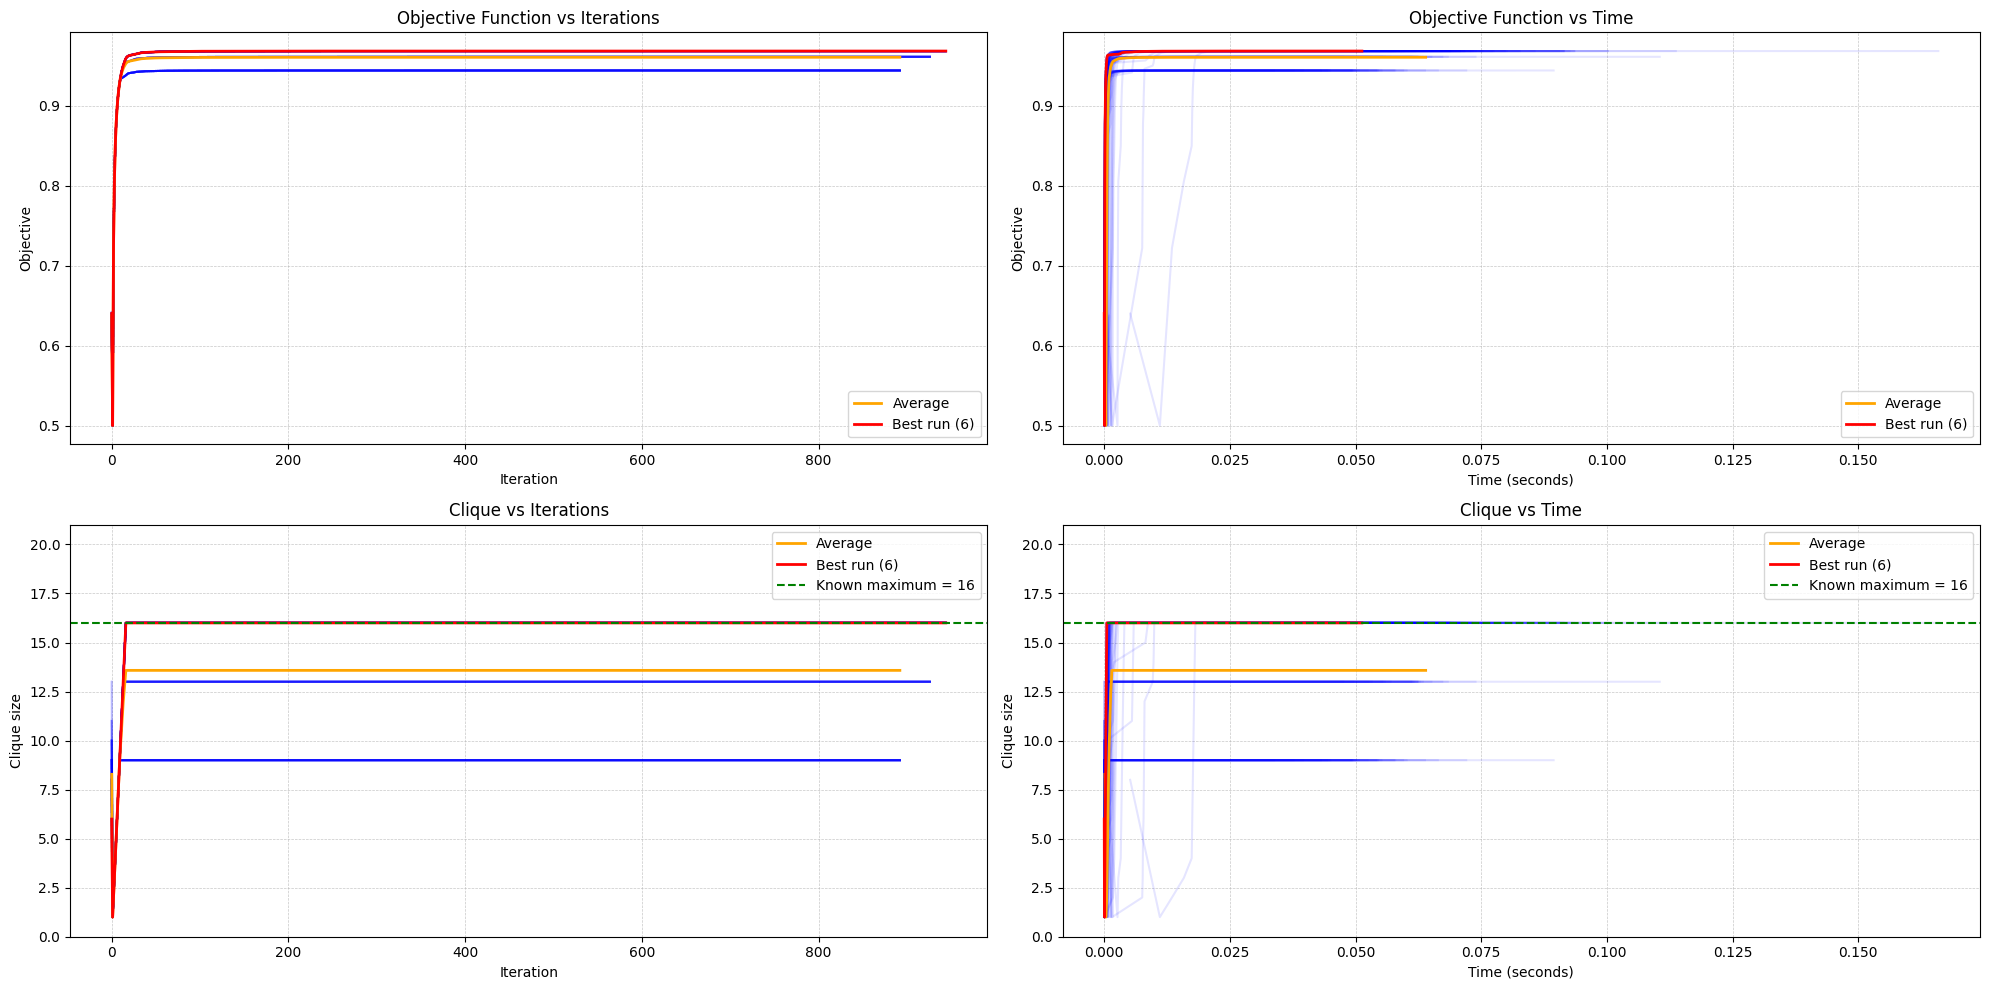

,Instances - Algorithm,Max,Mean,Std,CPU Time
0,hamming8-4 - afw_2norm_exact_line_search,16 (54),13.58,2.95,0.07


In [76]:
plots(results, max_clique=16)
experiment = dataset + ' - afw_2norm_exact_line_search'
results_stats(results, name = experiment)

In [ ]:
def multi_experiments(exp_num, algo_params, algo_names):

    if len(algo_params) != exp_num or len(algo_names) != exp_num:
        return 'Set the lists correctly!!!'

    algo_res = []
    
    for i in range(exp_num):
        results = experiments(fw_variant = algo_params[i][0],
                      regularization_method = algo_params[i][1],
                      step_strategy = algo_params[i][2],
                      alpha_2 = algo_params[i][3],
                      adj_mat = A,
                      n_trials = 100,
                      max_iter = 10000, 
                      tolerance = 1e-3,
                      supp_tolerance = 1e-7,
                      max_time = 60,
                      set_seed = 123,
                      qt = True)
        
        clique_sizes = [
            exp["Clique"][-1]
            for exp in results]
        best_clique = np.max(clique_sizes)
        max_clique_idx = [
            i for i, clique in enumerate(clique_sizes)
            if clique == best_clique]
        best_idx = min(
            max_clique_idx,
            key=lambda i: results[i]["Time"][-1])

        res = results[best_idx]
        res['Name'] = algo_names[i]
        
        algo_res.append(res)

        if i != exp_num-1:
            sleep(30) # Pausa di un minuto per lasciare raffreddare il computer

    return algo_res

In [151]:
def algorithms_plots(experiments, max_clique):

    fig, axes = plt.subplots(
        nrows=3,
        ncols=2,
        figsize=(20, 15))

    ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()
    
    # General grid
    for ax in axes.flatten():
        ax.grid(
            True,
            linestyle="--",
            linewidth=0.5,
            alpha=0.7)

    # Plots
    for exp in experiments:

        # Delta gap vs Iterations
        ax1.plot(exp["Delta gap"],
                 linewidth=2,
                 label=exp['Name'])

        # Delta gap vs Time
        ax2.plot(exp["Time"], exp["Delta gap"],
                 linewidth=2,
                 label=exp['Name'])
        
        # Objective vs Iterations
        ax3.plot(exp["Objective function"],
                 linewidth=2,
                 label=exp['Name'])

        # Objective vs Time
        ax4.plot(exp["Time"], exp["Objective function"],
                 linewidth=2,
                 label=exp['Name'])
        
        # Clique vs Iterations
        ax5.plot(exp["Clique"],
                 linewidth=2,
                 label=exp['Name'])
        
        # Clique vs Time
        ax6.plot(exp["Time"], exp["Clique"],
                 linewidth=2,
                 label=exp['Name'])

    # Maximum clique reference
    ax5.axhline(
        max_clique,
        linestyle="--",
        color="green",
        label=f"Known maximum = {max_clique}")

    ax6.axhline(
        max_clique,
        linestyle="--",
        color="green",
        label=f"Known maximum = {max_clique}")

    # Log scale for Delta gap
    ax1.set_yscale("log")
    ax2.set_yscale("log")

    # Titles and labels
    ax1.set_title("Delta gap vs Iterations")
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Delta gap")

    ax2.set_title("Delta gap vs Time")
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Delta gap")
    
    ax3.set_title("Objective Function vs Iterations")
    ax3.set_xlabel("Iteration")
    ax3.set_ylabel("Objective")
    
    ax4.set_title("Objective Function vs Time")
    ax4.set_xlabel("Time (seconds)")
    ax4.set_ylabel("Objective")
    
    ax5.set_title("Clique vs Iterations")
    ax5.set_xlabel("Iteration")
    ax5.set_ylabel("Clique size")    

    ax6.set_title("Clique vs Time")
    ax6.set_xlabel("Time (seconds)")
    ax6.set_ylabel("Clique size")

    # Y limits for clique plots
    all_cliques = [
        clique
        for exp in experiments
        for clique in exp["Clique"]]

    min_clique = min(all_cliques)

    ax5.set_ylim(
        min_clique - 1,
        max_clique + 5)

    ax6.set_ylim(
        min_clique - 1,
        max_clique + 5)

    ax1.legend()
    ax2.legend()
    ax3.legend()
    ax4.legend()
    ax5.legend()
    ax6.legend()

    plt.tight_layout()
    plt.show()

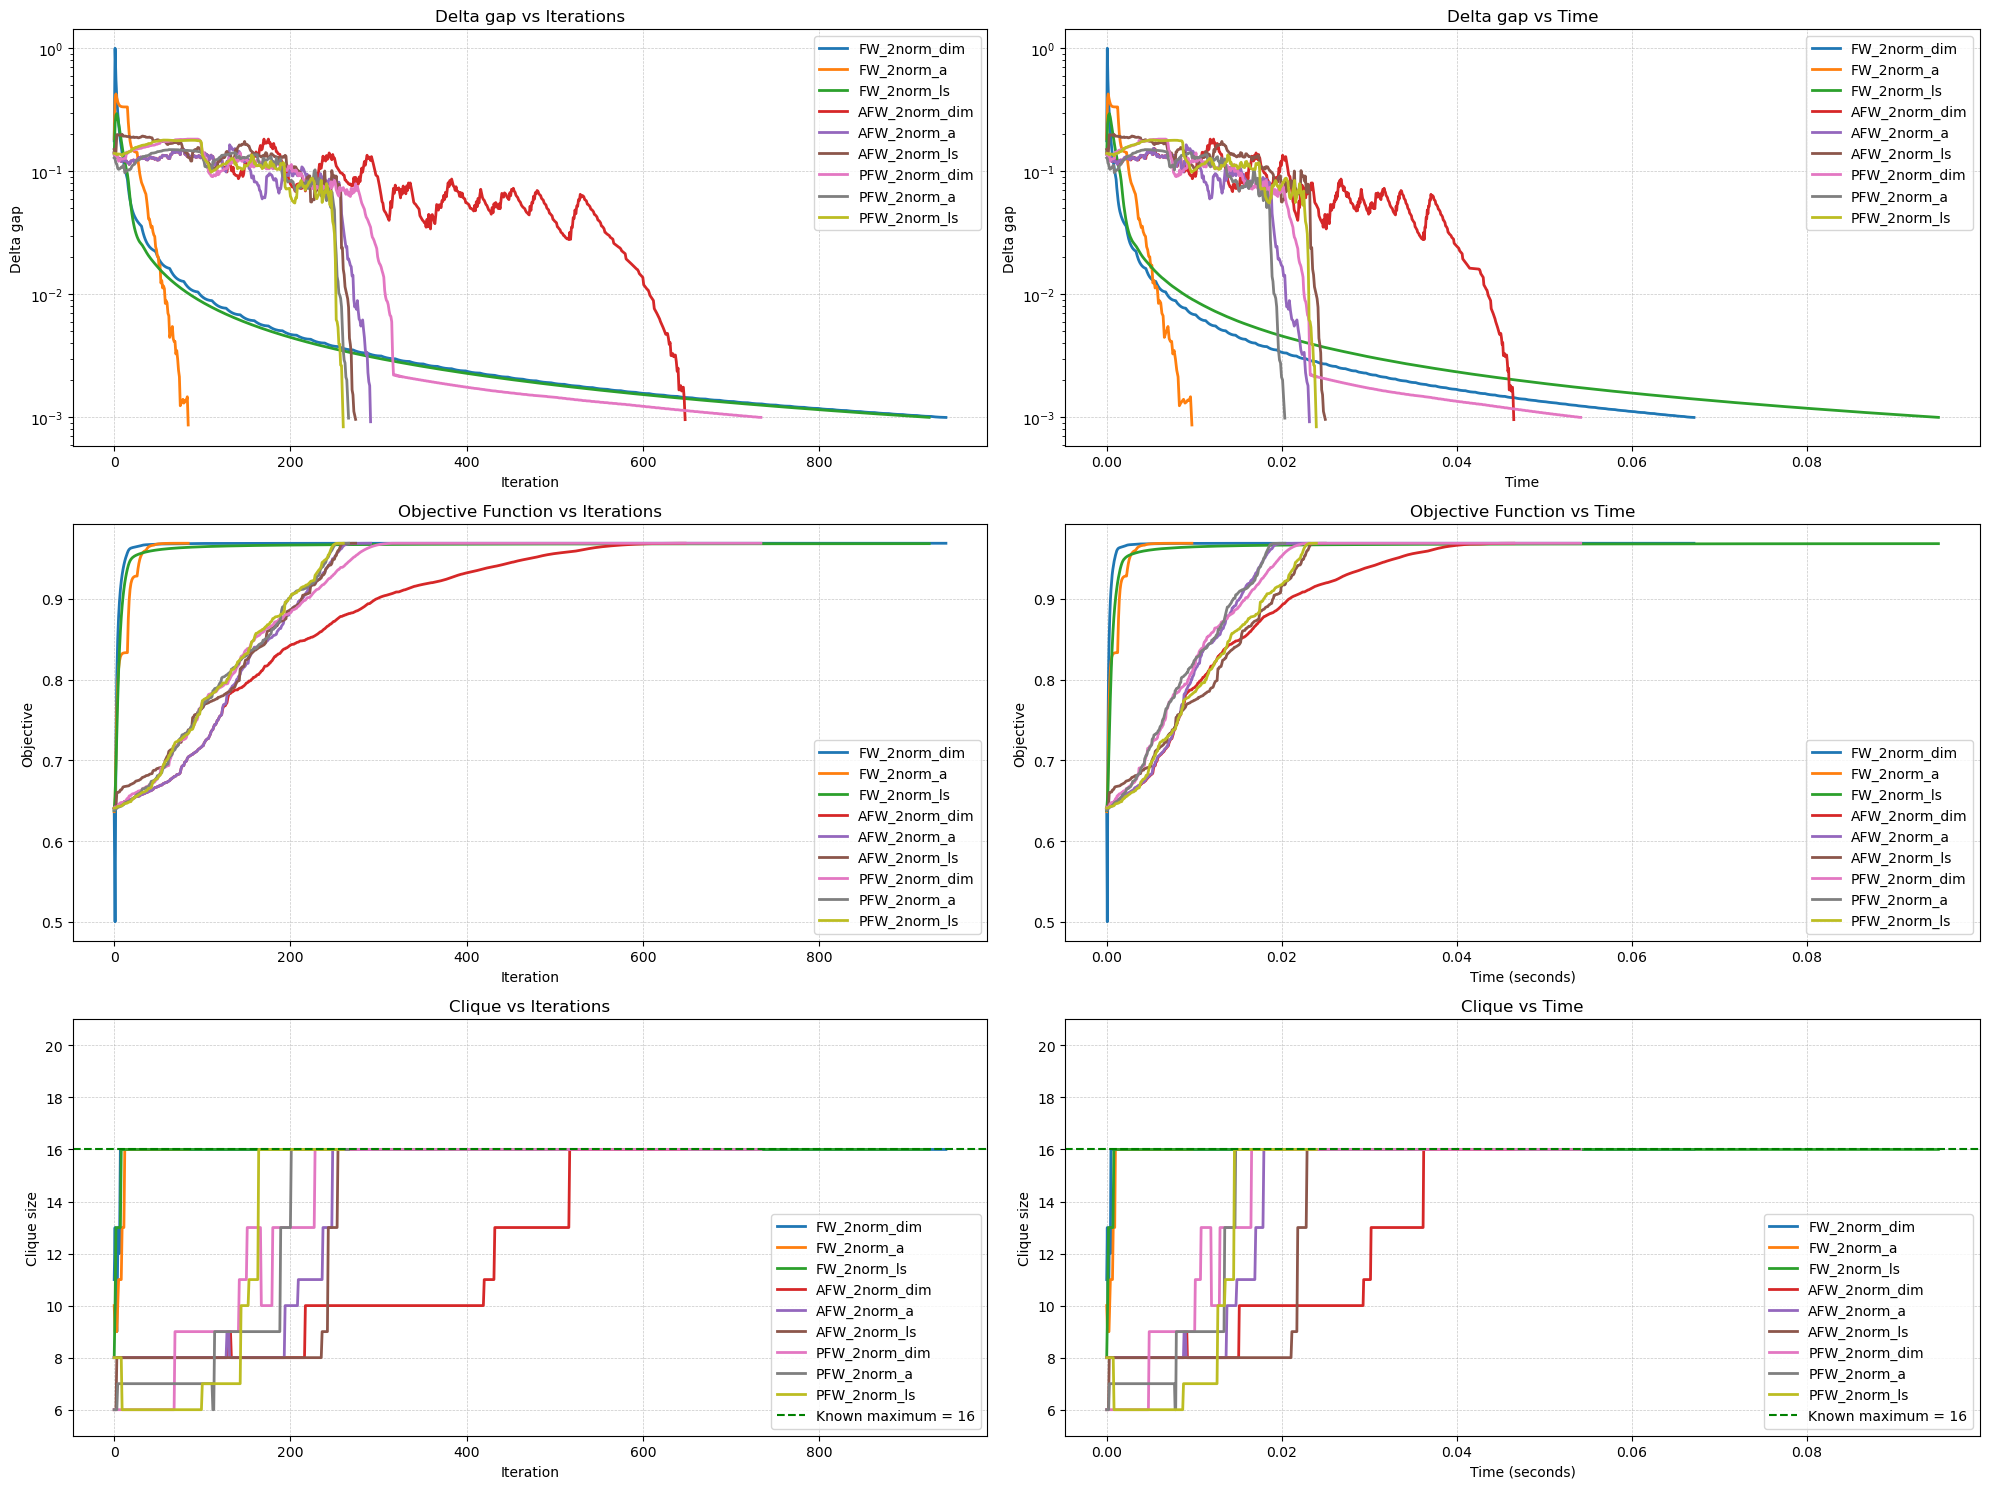

In [152]:
algo_params = [
    ['standard', '2norm', 'diminishing', 0.02],['standard', '2norm', 'armijo', 0.02],['standard', '2norm', 'line_search', 0.02],
    ['awaysteps', '2norm', 'diminishing', 0.02],['awaysteps', '2norm', 'armijo', 0.02],['awaysteps', '2norm', 'line_search', 0.02],
    ['pairwise', '2norm', 'diminishing', 0.02],['pairwise', '2norm', 'armijo', 0.02],['pairwise', '2norm', 'line_search', 0.02]
]
algo_names = [
    'FW_2norm_dim', 'FW_2norm_a', 'FW_2norm_ls',
    'AFW_2norm_dim', 'AFW_2norm_a', 'AFW_2norm_ls',
    'PFW_2norm_dim', 'PFW_2norm_a', 'PFW_2norm_ls',
]

algo_res = multi_experiments(9, algo_params, algo_names)

algorithms_plots(algo_res, max_clique=16)

In [153]:
# Adjacency matrix in csv to visualize in Gephi
#pd.DataFrame(A).to_csv(f'Data/{dataset}.csv')

In [ ]:
def prop5_stats(results, algorithm_name, max_clique):
    """
    Summary of the results according to Proposition 5.
    """

    n_runs = len(results)

    # --------------------------------------------------
    # 1. RELIABILITY
    # --------------------------------------------------

    converged_runs = [
        exp for exp in results
        if exp["Converged"]]

    certified_runs = [
        exp for exp in converged_runs
        if exp["Prop5_verified"]]

    maximal_support_runs = [
    exp for exp in converged_runs
    if exp["Support_is_maximal_clique"]]

    n_converged = len(converged_runs)
    n_certified = len(certified_runs)

    prop5_success_rate = (
        100 * n_certified / n_converged
        if n_converged > 0
        else 0.0)


    # --------------------------------------------------
    # 2. SOLUTION QUALITY
    # --------------------------------------------------

    if n_certified > 0:

        clique_sizes = np.array([
            exp["Support_size"]
            for exp in certified_runs])

        best_clique = np.max(clique_sizes)
        mean_clique = np.mean(clique_sizes)

        maximum_hit_rate = (
            100 * np.mean(
                clique_sizes == max_clique))

    else:

        best_clique = np.nan
        mean_clique = np.nan
        maximum_hit_rate = 0.0


    # --------------------------------------------------
    # 3. OPTIMIZATION EFFICIENCY
    # --------------------------------------------------

    if n_converged > 0:

        avg_iterations = np.mean([
            exp["Iterations"]
            for exp in converged_runs])

        avg_time = np.mean([
            exp["Time"][-1]
            for exp in converged_runs])

        avg_objective = np.mean([
            exp["Objective function"][-1]
            for exp in converged_runs])

    else:

        avg_iterations = np.nan
        avg_time = np.nan
        avg_objective = np.nan


    # --------------------------------------------------
    # 4. CONVERGENCE TO x(C)
    # --------------------------------------------------

    if len(maximal_support_runs) > 0:


        median_error = np.median([
        exp["Characteristic_error_inf"]
        for exp in maximal_support_runs])

    else:

        median_error = np.nan


    return {
        "Algorithm": algorithm_name,
        "Runs": n_runs,

        "Prop5 success (%)":
            prop5_success_rate,

        "Best certified clique": # C'era già su una funzione precedente
            best_clique,

        "Mean certified clique": # C'era già su una funzione precedente
            mean_clique,

        "Maximum hit rate (%)": # C'era già su una funzione precedente
            maximum_hit_rate,

        "Avg iterations": 
            avg_iterations,

        "Avg time (s)": # C'era già su una funzione precedente
            avg_time,

        "Avg final objective": # A cosa serve?
            avg_objective,

        # Non sarebbe meglio mettere direttamente la media dei pesi della cricca per vedere che si avvicinano a 1/|C|?
        "Median ||x-x(C)||inf":
            median_error
    }

Result FW STANDARD 2NORM LINE_SEARCH

In [35]:
fw_results = experiments(
    fw_variant='standard',
    regularization_method='2norm',
    step_strategy='diminishing',
    adj_mat=A,
    n_trials=10,
    max_iter=10000,
    tolerance=1e-3,
    supp_tolerance=1e-7,
    max_time=60,
    set_seed=123,
    qt=True
)

afw_results = experiments(
    fw_variant='awaysteps',
    regularization_method='2norm',
    step_strategy='line_search',
    adj_mat=A,
    n_trials=10,
    max_iter=10000,
    tolerance=1e-3,
    supp_tolerance=1e-7,
    max_time=60,
    set_seed=123,
    qt=True
)

pfw_results = experiments(
    fw_variant='pairwise',
    regularization_method='2norm',
    step_strategy='line_search',
    adj_mat=A,
    n_trials=10,
    max_iter=10000,
    tolerance=1e-3,
    supp_tolerance=1e-7,
    max_time=60,
    set_seed=123,
    qt=True
)

In [36]:
known_max_clique = 16

summary = [
    prop5_stats(
        fw_results,
        "FW",
        known_max_clique
    ),

    prop5_stats(
        afw_results,
        "AFW",
        known_max_clique
    ),

    prop5_stats(
        pfw_results,
        "PFW",
        known_max_clique
    )
]

summary_df = pd.DataFrame(summary)

summary_df = summary_df.round({
    "Convergence (%)": 2,
    "Prop5 success (%)": 2,
    "Mean certified clique": 2,
    "Maximum hit rate (%)": 2,
    "Avg iterations": 1,
    "Avg time (s)": 3,
    "Avg final objective": 6
})

summary_df

,Algorithm,Runs,Prop5 success (%),Best certified clique,Mean certified clique,Maximum hit rate (%),Avg iterations,Avg time (s),Avg final objective,Median ||x-x(C)||inf
0,FW,10,100.0,16,14.60,80.00,934.6,0.155,0.963886,0.000992
1,AFW,10,90.0,16,14.67,55.56,274.8,0.054,0.964822,0.000954
2,PFW,10,70.0,16,14.57,71.43,264.8,0.056,0.962648,0.000903
